# Multi-Sensor Synchronization Pipeline
**Xsens DOT (30 Hz) + OpenEarable → ELAN-annotated group CSV**

---
### Two-step approach
```
STEP 1 — Per-participant sync
         Xsens DOT  ──┐
                       ├─► align to ELAN sit-up anchor ─► {name}_aligned.csv
         OpenEarable ──┘   (one per participant, all on ELAN timeline)

STEP 2 — Group merge
         arda_aligned + rachel_aligned + bas_aligned
         ──► shared timeline ──► group_synchronized.csv
             (all sensors × 3 participants + all ELAN label tiers)
```
---
### Expected folder structure
```
group_1/
  elan/Group_1.csv
  xsens/arda.csv
  xsens/rachel.csv
  xsens/bas.csv
  openearable/arda/     ← *_acc.csv, *_gyro.csv, *_mgnt.csv, ...
  openearable/rachel/
  openearable/bas/
output/group_1/         ← created automatically
```

## Cell 0 — Imports & Configuration

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, resample_poly
from math import gcd
from pathlib import Path

# ── EDIT THESE ────────────────────────────────────────────────────────────────
GROUP_DIR    = '/content/drive/MyDrive/thesis/data/group_1'          # root folder for this group
OUTPUT_DIR   = 'output/group_1'   # results go here (created automatically)
PARTICIPANTS = ['arda', 'rachel', 'bas']  # must match openearable/ subfolder names

TARGET_HZ    = 30                 # common output sampling rate (Hz)
SYNC_LABEL   = 'synchronizaiton_move'  # exact string in ELAN (typo preserved)
SYNC_SEARCH_WINDOW_SEC = 300      # search last N seconds of each recording for sit-up peak
PEAK_MIN_HEIGHT = 14              # m/s² threshold for peak detection

# OpenEarable sensor file suffixes  →  output column names
OE_SENSORS = {
    'acc':       ['acc_x',  'acc_y',  'acc_z'],
    'gyro':      ['gyr_x',  'gyr_y',  'gyr_z'],
    'mgnt':      ['mag_x',  'mag_y',  'mag_z'],
    'baro':      ['baro'],
    'ppg':       ['ppg_r',  'ppg_ir', 'ppg_g', 'ppg_hr'],
    'env_temp':  ['env_temp'],
    'skin_temp': ['skin_temp'],
    'bone_acc':  ['bone_x', 'bone_y', 'bone_z'],
}

# ELAN participant / dyad / group tier names (col 0 of your ELAN export)
ELAN_PAIR_TIERS = ['Bas_Rachel', 'Bas_Arda', 'Arda_Rachel']
ELAN_GROUP_TIER = 'Whole_Group'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Configuration loaded')
print(f'  Group dir   : {GROUP_DIR}')
print(f'  Output dir  : {OUTPUT_DIR}')
print(f'  Participants: {PARTICIPANTS}')
print(f'  Target Hz   : {TARGET_HZ}')

Configuration loaded
  Group dir   : /content/drive/MyDrive/thesis/data/group_1
  Output dir  : output/group_1
  Participants: ['arda', 'rachel', 'bas']
  Target Hz   : 30


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 1 — Helper Functions

In [3]:
# ── I/O ───────────────────────────────────────────────────────────────────────

def load_oe_sensor(filepath):
    """Load one OpenEarable CSV.
    Returns (DataFrame[time_us, v0, v1, ...], actual_hz).
    Timestamps are Unix microseconds. Last status-flag column is dropped."""
    df = pd.read_csv(filepath, header=None)
    df = df.iloc[:, :-1]
    df.columns = ['time_us'] + [f'v{i}' for i in range(len(df.columns) - 1)]
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df.loc[df[col].abs() > 1e4, col] = np.nan   # bone_acc has ADC values ~1e4, acc ~10
    df = df.interpolate().dropna().reset_index(drop=True)
    df['time_us'] = df['time_us'].astype(np.int64)
    hz = 1e6 / np.median(np.diff(df['time_us'].values))
    return df, hz

def load_xsens(filepath):
    """Load Xsens DOT CSV.
    SampleTimeFine is in microseconds (relative 32-bit counter).
    Handles corrupt acc rows and 32-bit timestamp wrap-around."""
    df = pd.read_csv(filepath, skipinitialspace=True)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

    # Force all signal columns to numeric
    for col in df.columns:
        if col != 'PacketCounter':
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Step 1: clean corrupt rows (timestamps AND acc) BEFORE wrap fix
    # Corrupt rows have both bad timestamps and bad acc values
    # Identify by acc magnitude > physical limit (~100 m/s2 for human motion)
    acc_bad = ((df['Acc_X'].abs() > 100) |
               (df['Acc_Y'].abs() > 100) |
               (df['Acc_Z'].abs() > 100))
    df.loc[acc_bad, ['SampleTimeFine','Acc_X','Acc_Y','Acc_Z',
                     'Gyr_X','Gyr_Y','Gyr_Z','Euler_X','Euler_Y','Euler_Z']] = np.nan
    # Interpolate timestamps linearly before wrap fix
    df['SampleTimeFine'] = df['SampleTimeFine'].interpolate()
    df[['Acc_X','Acc_Y','Acc_Z','Gyr_X','Gyr_Y','Gyr_Z',
        'Euler_X','Euler_Y','Euler_Z']] = df[['Acc_X','Acc_Y','Acc_Z',
        'Gyr_X','Gyr_Y','Gyr_Z','Euler_X','Euler_Y','Euler_Z']].interpolate()

    # Step 2: fix 32-bit timestamp wrap-around AFTER corrupt rows are removed
    ts = df['SampleTimeFine'].values.copy().astype(np.float64)
    WRAP = 2**32
    for i in range(1, len(ts)):
        if ts[i] < ts[i-1] - WRAP/2:   # real wrap: diff ~ -4e9
            ts[i:] += WRAP
    df['SampleTimeFine'] = ts
    df = df.reset_index(drop=True)

    df['time_rel_sec'] = (df['SampleTimeFine'] - df['SampleTimeFine'].iloc[0]) / 1e6
    hz = 1e6 / np.median(np.diff(df['SampleTimeFine'].values))
    return df, hz

def load_elan(filepath):
    """Load ELAN export CSV (no header)."""
    df = pd.read_csv(filepath, header=None)
    df.columns = ['participant', 'tier', 'begin_hms', 'begin_sec',
                  'end_hms', 'end_sec', 'dur_hms', 'dur_sec', 'label']
    df['label'] = df['label'].str.strip()
    return df

# ── Signal ────────────────────────────────────────────────────────────────────

def xs_acc_mag(df):
    return np.sqrt(df['Acc_X']**2 + df['Acc_Y']**2 + df['Acc_Z']**2).values

def oe_acc_mag(df):
    return np.sqrt(df['v0']**2 + df['v1']**2 + df['v2']**2).values

def resample_array(data, orig_hz, target_hz):
    """Poly-phase resample. Works for 1-D or 2-D (n_samples x n_channels)."""
    g = gcd(round(orig_hz), target_hz)
    up, down = target_hz // g, round(orig_hz) // g
    if data.ndim == 1:
        return resample_poly(data, up, down)
    return np.column_stack([resample_poly(data[:, c], up, down)
                            for c in range(data.shape[1])])

def interp_to_grid(signal, src_time, dst_time):
    """Linearly interpolate signal from src_time onto dst_time."""
    if signal.ndim == 1:
        return np.interp(dst_time, src_time, signal)
    return np.column_stack([np.interp(dst_time, src_time, signal[:, c])
                            for c in range(signal.shape[1])])

# ── ELAN ──────────────────────────────────────────────────────────────────────

def get_elan_sync_time(elan_df):
    """Return midpoint time (s) of the synchronizaiton_move annotation."""
    row = elan_df[elan_df['label'] == SYNC_LABEL]
    if len(row) == 0:
        raise ValueError(f"Sync label '{SYNC_LABEL}' not found in ELAN file!")
    return float((row['begin_sec'].values[0] + row['end_sec'].values[0]) / 2)

def assign_labels(time_arr, elan_df, participant_filter):
    """Map ELAN annotations onto time_arr. Returns array of strings."""
    labels = np.full(len(time_arr), '', dtype=object)
    subset = elan_df[elan_df['participant'] == participant_filter]
    for _, row in subset.iterrows():
        mask = (time_arr >= row['begin_sec']) & (time_arr <= row['end_sec'])
        labels[mask] = row['label']
    return labels

print('Helper functions ready')

Helper functions ready


In [4]:
import os

# Check what's actually at your GROUP_DIR
print("GROUP_DIR =", GROUP_DIR)
print("Exists?", os.path.exists(GROUP_DIR))
print()

# Walk the full folder tree
for root, dirs, files in os.walk(GROUP_DIR):
    level = root.replace(GROUP_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')

GROUP_DIR = /content/drive/MyDrive/thesis/data/group_1
Exists? True

group_1/
  elan/
    Group_1.csv
  openearable/
    bas/
      bas_baro.csv
      bas_acc.csv
      bas_env_temp.csv
      bas_bone_acc.csv
      bas_skin_temp.csv
      bas_gyro.csv
      bas_ppg.csv
      bas_mgnt.csv
    arda/
      arda_bone_acc.csv
      arda_skin_temp.csv
      arda_baro.csv
      arda_ppg.csv
      arda_env_temp.csv
      arda_acc.csv
      arda_mgnt.csv
      arda_gyro.csv
    rachel/
      rachel_gyro.csv
      rachel_acc.csv
      rachel_bone_acc.csv
      rachel_baro.csv
      rachel_env_temp.csv
      rachel_mgnt.csv
      rachel_ppg.csv
      rachel_skin_temp.csv
  xsens/
    arda.csv
    rachel.csv
    bas.csv


## Cell 2 — Load Raw Data & Sanity Check

In [5]:
# Load ELAN
elan_path   = glob.glob(os.path.join(GROUP_DIR, 'elan', '*.csv'))[0]
elan_df     = load_elan(elan_path)
elan_sync_t = get_elan_sync_time(elan_df)

print(f'ELAN file   : {os.path.basename(elan_path)}')
print(f'Annotations : {len(elan_df)} rows')
print(f'Participants: {sorted(elan_df["participant"].unique())}')
print(f'Sync anchor : {elan_sync_t:.3f} s')
print()

# Load each participant
raw = {}   # raw[name] = {'xs': (df, hz), 'oe': {sensor_key: (df, hz)}}

for name in PARTICIPANTS:
    name_cap = name.capitalize()
    print(f'── {name_cap} ──────────────────────────')

    # Xsens: try name-prefixed file first, then any .csv in xsens/
    xs_matches = (glob.glob(os.path.join(GROUP_DIR, 'xsens', f'{name}*.csv'))
               or glob.glob(os.path.join(GROUP_DIR, 'xsens', f'{name_cap}*.csv')))
    if not xs_matches:
        raise FileNotFoundError(f'No Xsens file for {name} in {GROUP_DIR}/xsens/')
    xs_df, xs_hz = load_xsens(xs_matches[0])
    print(f'  Xsens : {os.path.basename(xs_matches[0])}')
    print(f'          {len(xs_df):,} rows | {xs_hz:.1f} Hz | {xs_df["time_rel_sec"].max()/60:.1f} min')

    # OpenEarable: find participant subfolder (case-insensitive)
    oe_dirs = (glob.glob(os.path.join(GROUP_DIR, 'openearable', name))
            or glob.glob(os.path.join(GROUP_DIR, 'openearable', name_cap)))
    if not oe_dirs:
        raise FileNotFoundError(f'No OpenEarable folder for {name} in {GROUP_DIR}/openearable/')
    oe_dir = oe_dirs[0]

    oe_sensors = {}
    for sensor_key in OE_SENSORS:
        matches = glob.glob(os.path.join(oe_dir, f'*_{sensor_key}.csv'))
        if matches:
            oe_sensors[sensor_key] = load_oe_sensor(matches[0])

    oe_acc_df, oe_acc_hz = oe_sensors['acc']
    oe_dur = (oe_acc_df['time_us'].iloc[-1] - oe_acc_df['time_us'].iloc[0]) / 1e6
    print(f'  OE    : {os.path.basename(oe_dir)}/')
    print(f'          {len(oe_sensors)} sensors | acc {oe_acc_hz:.1f} Hz | {oe_dur/60:.1f} min')
    missing = [k for k in OE_SENSORS if k not in oe_sensors]
    if missing:
        print(f'          WARNING — missing sensors: {missing}')

    raw[name] = {'xs': (xs_df, xs_hz), 'oe': oe_sensors}
    print()

print('All raw data loaded')

ELAN file   : Group_1.csv
Annotations : 176 rows
Participants: ['Arda', 'Arda_Rachel', 'Bas', 'Bas_Arda', 'Bas_Rachel', 'Rachel', 'Whole_Group']
Sync anchor : 1829.318 s

── Arda ──────────────────────────
  Xsens : arda.csv
          60,391 rows | 30.0 Hz | 33.6 min
  OE    : arda/
          8 sensors | acc 50.0 Hz | 46.1 min

── Rachel ──────────────────────────
  Xsens : rachel.csv
          59,997 rows | 30.0 Hz | 105.1 min
  OE    : rachel/
          8 sensors | acc 50.0 Hz | 33.3 min

── Bas ──────────────────────────
  Xsens : bas.csv
          60,389 rows | 30.0 Hz | 33.5 min
  OE    : bas/
          8 sensors | acc 50.0 Hz | 33.3 min

All raw data loaded


In [6]:
# Quick check on raw loaded values per participant
for name in PARTICIPANTS:
    xs_df, xs_hz = raw[name]['xs']
    print(f"{name}: Acc_X range = {xs_df['Acc_X'].min():.3f} to {xs_df['Acc_X'].max():.3f}  |  dtype = {xs_df['Acc_X'].dtype}")

arda: Acc_X range = -32.044 to 17.442  |  dtype = float64
rachel: Acc_X range = -59.456 to 48.548  |  dtype = float64
bas: Acc_X range = -14.352 to 35.851  |  dtype = float64


---
## Cell 3 — Sync Peak Detection & Visual Confirmation

Auto-detects the sit-up sync peak in the last `SYNC_SEARCH_WINDOW_SEC` of each recording.

- **Red dashed line** = detected peak (used for alignment)
- **Orange dotted lines** = other candidate peaks above threshold
- **Gray dashed line** = `PEAK_MIN_HEIGHT` threshold

If any peak looks wrong → run **Cell 3b** to override it manually.

Bas         Xsens peak: 1985.27s   OE peak: 2754.56s   Inter-device diff: 769.28s
Bas         Xsens peak: 6277.94s   OE peak: 1985.93s   Inter-device diff: 4292.01s
Bas         Xsens peak: 1995.61s   OE peak: 1985.13s   Inter-device diff: 10.48s


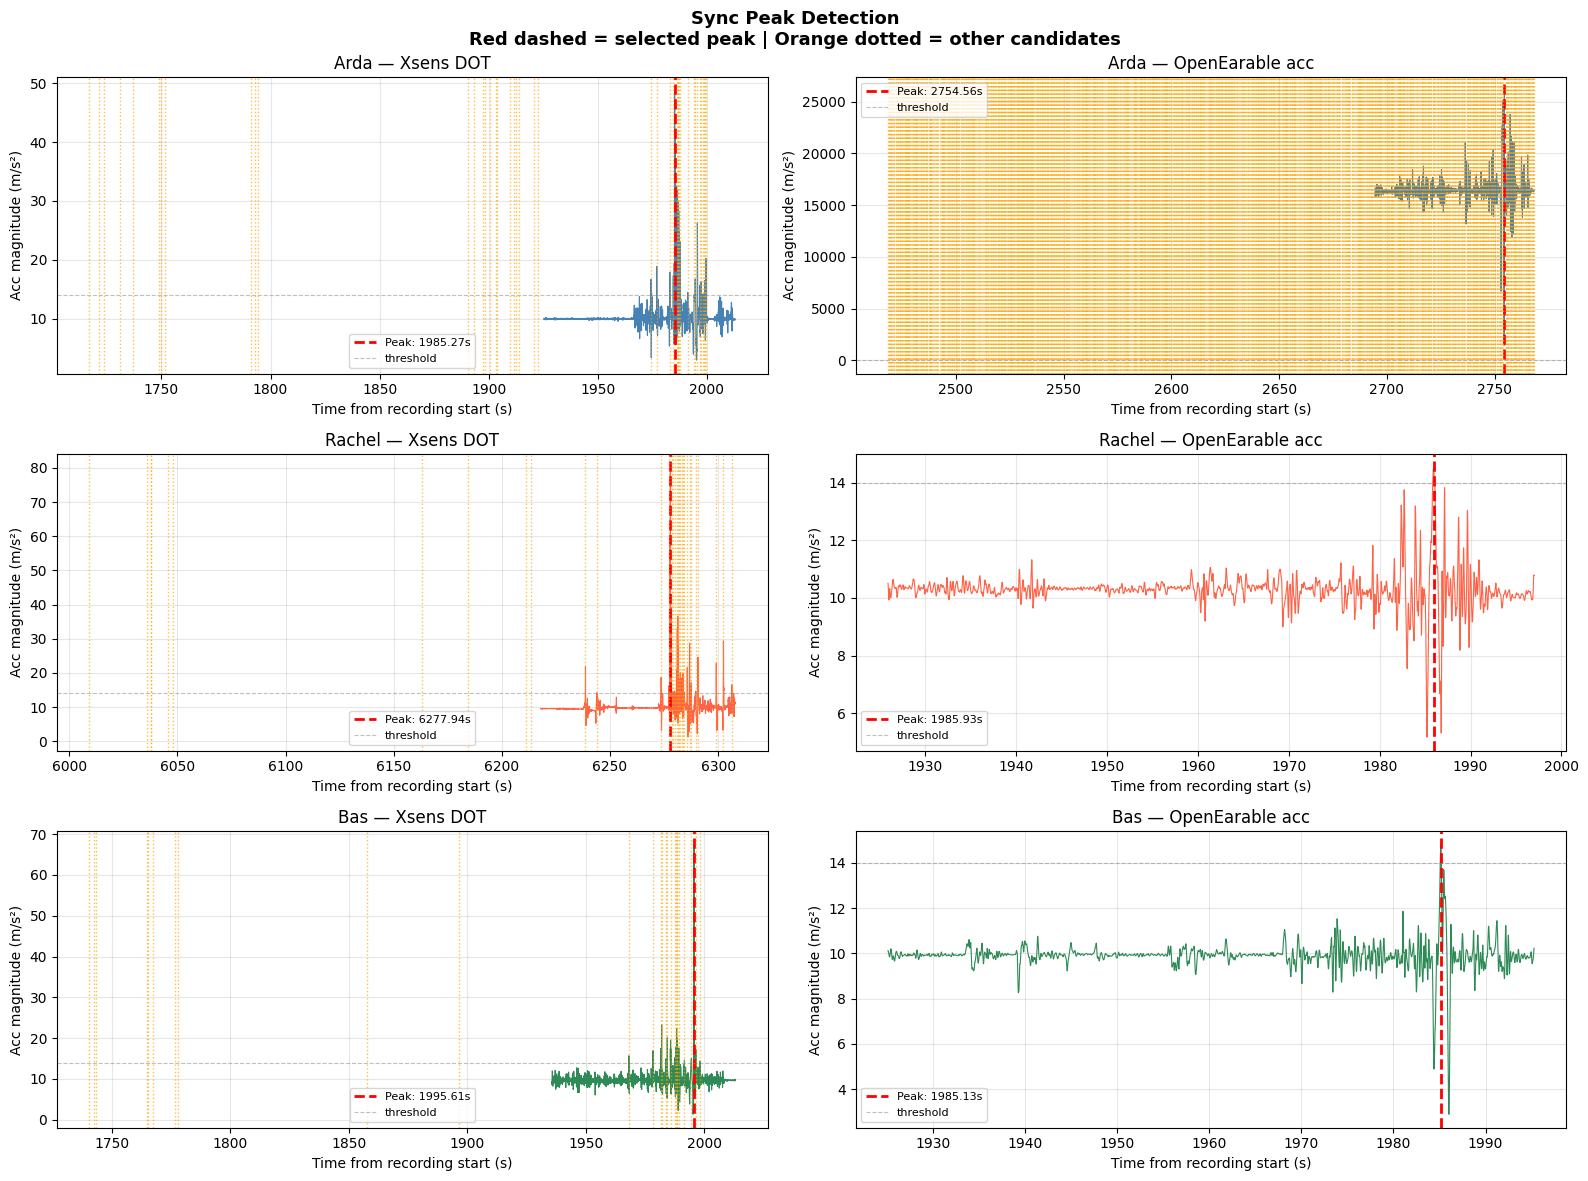

Plot saved to output/group_1/sync_peak_confirmation.png

If any peak is wrong  →  run Cell 3b to override.
If all peaks look good →  skip Cell 3b, continue to Cell 4.


In [7]:
def detect_sync_peak(time_sec, acc_mag, search_window=SYNC_SEARCH_WINDOW_SEC):
    """
    Find the sit-up sync event in the last `search_window` seconds.
    Returns (best_peak_time_sec, all_candidate_times).
    """
    time_sec = np.asarray(time_sec)
    acc_mag  = np.asarray(acc_mag, dtype=float)
    mask     = time_sec > (time_sec[-1] - search_window)
    t_win, a_win = time_sec[mask], acc_mag[mask]

    peaks, _ = find_peaks(a_win, height=PEAK_MIN_HEIGHT, distance=10)
    if len(peaks) == 0:
        best_idx = int(np.argmax(a_win))   # fallback: absolute max in window
    else:
        best_idx = peaks[int(np.argmax(a_win[peaks]))]

    return float(t_win[best_idx]), t_win[peaks] if len(peaks) > 0 else np.array([t_win[best_idx]])


# ── Auto-detect for all participants ──────────────────────────────────────────
sync_peaks = {}

for name in PARTICIPANTS:
    xs_df, xs_hz   = raw[name]['xs']
    oe_acc_df, _   = raw[name]['oe']['acc']

    xs_t   = xs_df['time_rel_sec'].values
    oe_t   = (oe_acc_df['time_us'].values - oe_acc_df['time_us'].values[0]) / 1e6

    xs_mag = xs_acc_mag(xs_df)
    oe_mag = oe_acc_mag(oe_acc_df)

    xs_peak, xs_all = detect_sync_peak(xs_t, xs_mag)
    oe_peak, oe_all = detect_sync_peak(oe_t, oe_mag)

    sync_peaks[name] = {
        'xs': xs_peak, 'oe': oe_peak,
        'xs_time': xs_t, 'xs_mag': xs_mag, 'xs_all': xs_all,
        'oe_time': oe_t, 'oe_mag': oe_mag, 'oe_all': oe_all,
    }
    inter_device_diff = abs((elan_sync_t - xs_peak) - (elan_sync_t - oe_peak))
    print(f'{name.capitalize():<10s}  Xsens peak: {xs_peak:.2f}s   OE peak: {oe_peak:.2f}s   '
          f'Inter-device diff: {inter_device_diff:.2f}s')

# ── Confirmation plot ─────────────────────────────────────────────────────────
PLOT_WINDOW = 60   # seconds shown either side of the detected peak
colors      = ['steelblue', 'tomato', 'seagreen']

fig, axes = plt.subplots(len(PARTICIPANTS), 2,
                         figsize=(16, 4 * len(PARTICIPANTS)), squeeze=False)
fig.suptitle('Sync Peak Detection\n'
             'Red dashed = selected peak | Orange dotted = other candidates',
             fontsize=13, fontweight='bold')

for i, (name, color) in enumerate(zip(PARTICIPANTS, colors)):
    sp = sync_peaks[name]
    for j, (device, t_arr, mag, peak_t, all_peaks) in enumerate([
        ('Xsens DOT',      sp['xs_time'], sp['xs_mag'], sp['xs'], sp['xs_all']),
        ('OpenEarable acc', sp['oe_time'], sp['oe_mag'], sp['oe'], sp['oe_all']),
    ]):
        ax = axes[i, j]
        win = (t_arr >= peak_t - PLOT_WINDOW) & (t_arr <= peak_t + PLOT_WINDOW)
        ax.plot(t_arr[win], mag[win], color=color, lw=0.8)
        ax.axvline(peak_t, color='red',  lw=2,   ls='--', label=f'Peak: {peak_t:.2f}s')
        ax.axhline(PEAK_MIN_HEIGHT, color='gray', lw=0.8, ls='--', alpha=0.5, label='threshold')
        for pt in all_peaks:
            if abs(pt - peak_t) > 0.5:
                ax.axvline(pt, color='orange', lw=1, ls=':', alpha=0.7)
        ax.set_title(f'{name.capitalize()} — {device}')
        ax.set_xlabel('Time from recording start (s)')
        ax.set_ylabel('Acc magnitude (m/s\u00b2)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'sync_peak_confirmation.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Plot saved to {fig_path}')
print()
print('If any peak is wrong  →  run Cell 3b to override.')
print('If all peaks look good →  skip Cell 3b, continue to Cell 4.')

## Cell 3b — Manual Peak Override *(skip if Cell 3 looks correct)*

Set the correct time (in seconds from that device's recording start) for any wrong peak.  
Leave as `None` to keep the auto-detected value.

In [8]:
# ── SET OVERRIDES HERE (None = keep auto-detected value) ─────────────────────
MANUAL_OVERRIDES = {
    'arda':   {'xs': None, 'oe': None},
    'rachel': {'xs': None, 'oe': None},
    'bas':    {'xs': None, 'oe': None},
}
# Example — if Rachel's Xsens peak was wrong:
#   'rachel': {'xs': 1854.0, 'oe': None}

# ── Apply ─────────────────────────────────────────────────────────────────────
any_changed = False
for name, overrides in MANUAL_OVERRIDES.items():
    for device, val in overrides.items():
        if val is not None:
            old = sync_peaks[name][device]
            sync_peaks[name][device] = float(val)
            print(f'  OVERRIDE  {name} {device}: {old:.3f}s  ->  {val:.3f}s')
            any_changed = True
if not any_changed:
    print('No overrides applied.')

print()
print('Final sync peaks:')
print(f'  {"Name":<10}  {"Xsens peak":>12}  {"XS offset":>10}  {"OE peak":>10}  {"OE offset":>10}')
print('  ' + '-'*58)
for name in PARTICIPANTS:
    xs_t   = sync_peaks[name]['xs']
    oe_t   = sync_peaks[name]['oe']
    xs_off = elan_sync_t - xs_t
    oe_off = elan_sync_t - oe_t
    print(f'  {name:<10}  {xs_t:>12.3f}s  {xs_off:>+10.3f}s  {oe_t:>10.3f}s  {oe_off:>+10.3f}s')

No overrides applied.

Final sync peaks:
  Name          Xsens peak   XS offset     OE peak   OE offset
  ----------------------------------------------------------
  arda            1985.273s    -155.955s    2754.556s    -925.238s
  rachel          6277.940s   -4448.622s    1985.932s    -156.614s
  bas             1995.607s    -166.289s    1985.131s    -155.813s


---
## STEP 1 — Per-Participant Synchronization
### Cell 4 — Align & Resample Each Participant

For each participant:
1. Compute time offset → maps Xsens and OE onto the ELAN video timeline
2. Resample all sensors to `TARGET_HZ`
3. Assign ELAN labels (individual tier)
4. Save `{name}_aligned.csv`

In [9]:
aligned = {}   # aligned[name] = DataFrame on ELAN timeline

for name in PARTICIPANTS:
    name_cap   = name.capitalize()
    xs_df, xs_hz = raw[name]['xs']
    oe_sensors   = raw[name]['oe']
    print(f'STEP 1  {name_cap}  ─────────────────────────────────────────────')

    # ── Offsets ───────────────────────────────────────────────────────────────
    xs_off = elan_sync_t - sync_peaks[name]['xs']   # add to xs_time_rel → ELAN time
    oe_off = elan_sync_t - sync_peaks[name]['oe']   # add to oe_time_rel → ELAN time
    print(f'  Xsens offset : {xs_off:+.3f}s  (sensor started at ELAN t={-xs_off:.1f}s)')
    print(f'  OE offset    : {oe_off:+.3f}s  (sensor started at ELAN t={-oe_off:.1f}s)')

    xs_elan_t  = xs_df['time_rel_sec'].values + xs_off
    oe_acc_df  = oe_sensors['acc'][0]
    oe_time_rel = (oe_acc_df['time_us'].values - oe_acc_df['time_us'].values[0]) / 1e6
    oe_elan_t  = oe_time_rel + oe_off

    # ── Unified time axis (overlap of all devices, at TARGET_HZ) ─────────────
    t_starts = [xs_elan_t[0], oe_elan_t[0]]
    t_ends   = [xs_elan_t[-1], oe_elan_t[-1]]
    for sensor_key, (df_s, _) in oe_sensors.items():
        t_s = (df_s['time_us'].values - df_s['time_us'].values[0]) / 1e6 + oe_off
        t_starts.append(t_s[0]);  t_ends.append(t_s[-1])

    t_start   = max(t_starts)
    t_end     = min(t_ends)
    t_unified = np.arange(t_start, t_end, 1.0 / TARGET_HZ)
    print(f'  Timeline     : {t_start:.1f}s -> {t_end:.1f}s  '
          f'({len(t_unified):,} samples @ {TARGET_HZ} Hz = {(t_end-t_start)/60:.1f} min)')

    out = {'time_sec': t_unified}

    # ── Xsens ─────────────────────────────────────────────────────────────────
    xs_cols_in  = ['Euler_X','Euler_Y','Euler_Z','Acc_X','Acc_Y','Acc_Z','Gyr_X','Gyr_Y','Gyr_Z']
    xs_cols_out = ['xs_euler_x','xs_euler_y','xs_euler_z',
                   'xs_acc_x',  'xs_acc_y',  'xs_acc_z',
                   'xs_gyr_x',  'xs_gyr_y',  'xs_gyr_z']
    xs_sig     = xs_df[xs_cols_in].values
    xs_rs      = resample_array(xs_sig, xs_hz, TARGET_HZ)
    xs_t_rs    = np.linspace(xs_elan_t[0], xs_elan_t[-1], len(xs_rs))
    for k, col in enumerate(xs_cols_out):
        out[col] = interp_to_grid(xs_rs[:, k], xs_t_rs, t_unified)

    # ── OpenEarable sensors ───────────────────────────────────────────────────
    for sensor_key, col_names in OE_SENSORS.items():
        if sensor_key not in oe_sensors:
            continue
        df_s, hz_s = oe_sensors[sensor_key]
        t_s   = (df_s['time_us'].values - df_s['time_us'].values[0]) / 1e6 + oe_off
        sig   = df_s.iloc[:, 1:].values
        rs    = resample_array(sig, hz_s, TARGET_HZ)
        t_rs  = np.linspace(t_s[0], t_s[-1], len(rs))
        for k, col in enumerate(col_names[:sig.shape[1]]):
            out[f'oe_{col}'] = interp_to_grid(rs[:, k], t_rs, t_unified)

    # ── ELAN labels ───────────────────────────────────────────────────────────
    out['label_individual']  = assign_labels(t_unified, elan_df, name_cap)
    for tier in ELAN_PAIR_TIERS:
        if name_cap in tier:
            out[f'label_{tier.lower()}'] = assign_labels(t_unified, elan_df, tier)
    out['label_whole_group'] = assign_labels(t_unified, elan_df, ELAN_GROUP_TIER)

    # ── Save ──────────────────────────────────────────────────────────────────
    out_df   = pd.DataFrame(out)
    out_path = os.path.join(OUTPUT_DIR, f'{name}_aligned.csv')
    out_df.to_csv(out_path, index=False)
    n_labeled = (out_df['label_individual'] != '').sum()
    print(f'  Saved  -> {out_path}  '
          f'({out_df.shape[1]} cols | {n_labeled:,}/{len(out_df):,} samples labeled)')
    aligned[name] = out_df
    print()

print('STEP 1 complete')

STEP 1  Arda  ─────────────────────────────────────────────
  Xsens offset : -155.955s  (sensor started at ELAN t=156.0s)
  OE offset    : -925.238s  (sensor started at ELAN t=925.2s)
  Timeline     : -156.0s -> 1074.9s  (36,927 samples @ 30 Hz = 20.5 min)
  Saved  -> output/group_1/arda_aligned.csv  (33 cols | 1,947/36,927 samples labeled)

STEP 1  Rachel  ─────────────────────────────────────────────
  Xsens offset : -4448.622s  (sensor started at ELAN t=4448.6s)
  OE offset    : -156.614s  (sensor started at ELAN t=156.6s)
  Timeline     : -156.6s -> 1839.4s  (59,880 samples @ 30 Hz = 33.3 min)
  Saved  -> output/group_1/rachel_aligned.csv  (33 cols | 5,127/59,880 samples labeled)

STEP 1  Bas  ─────────────────────────────────────────────
  Xsens offset : -166.289s  (sensor started at ELAN t=166.3s)
  OE offset    : -155.813s  (sensor started at ELAN t=155.8s)
  Timeline     : -155.8s -> 1838.3s  (59,823 samples @ 30 Hz = 33.2 min)
  Saved  -> output/group_1/bas_aligned.csv  (33 co

## Cell 5 — Verify Step 1 Alignment

All three Xsens acc-magnitude signals are plotted on the **shared ELAN timeline**.  
The large peak should sit exactly on the black dashed line (ELAN sync annotation).  
If it doesn't → return to Cell 3b and adjust the relevant peak.

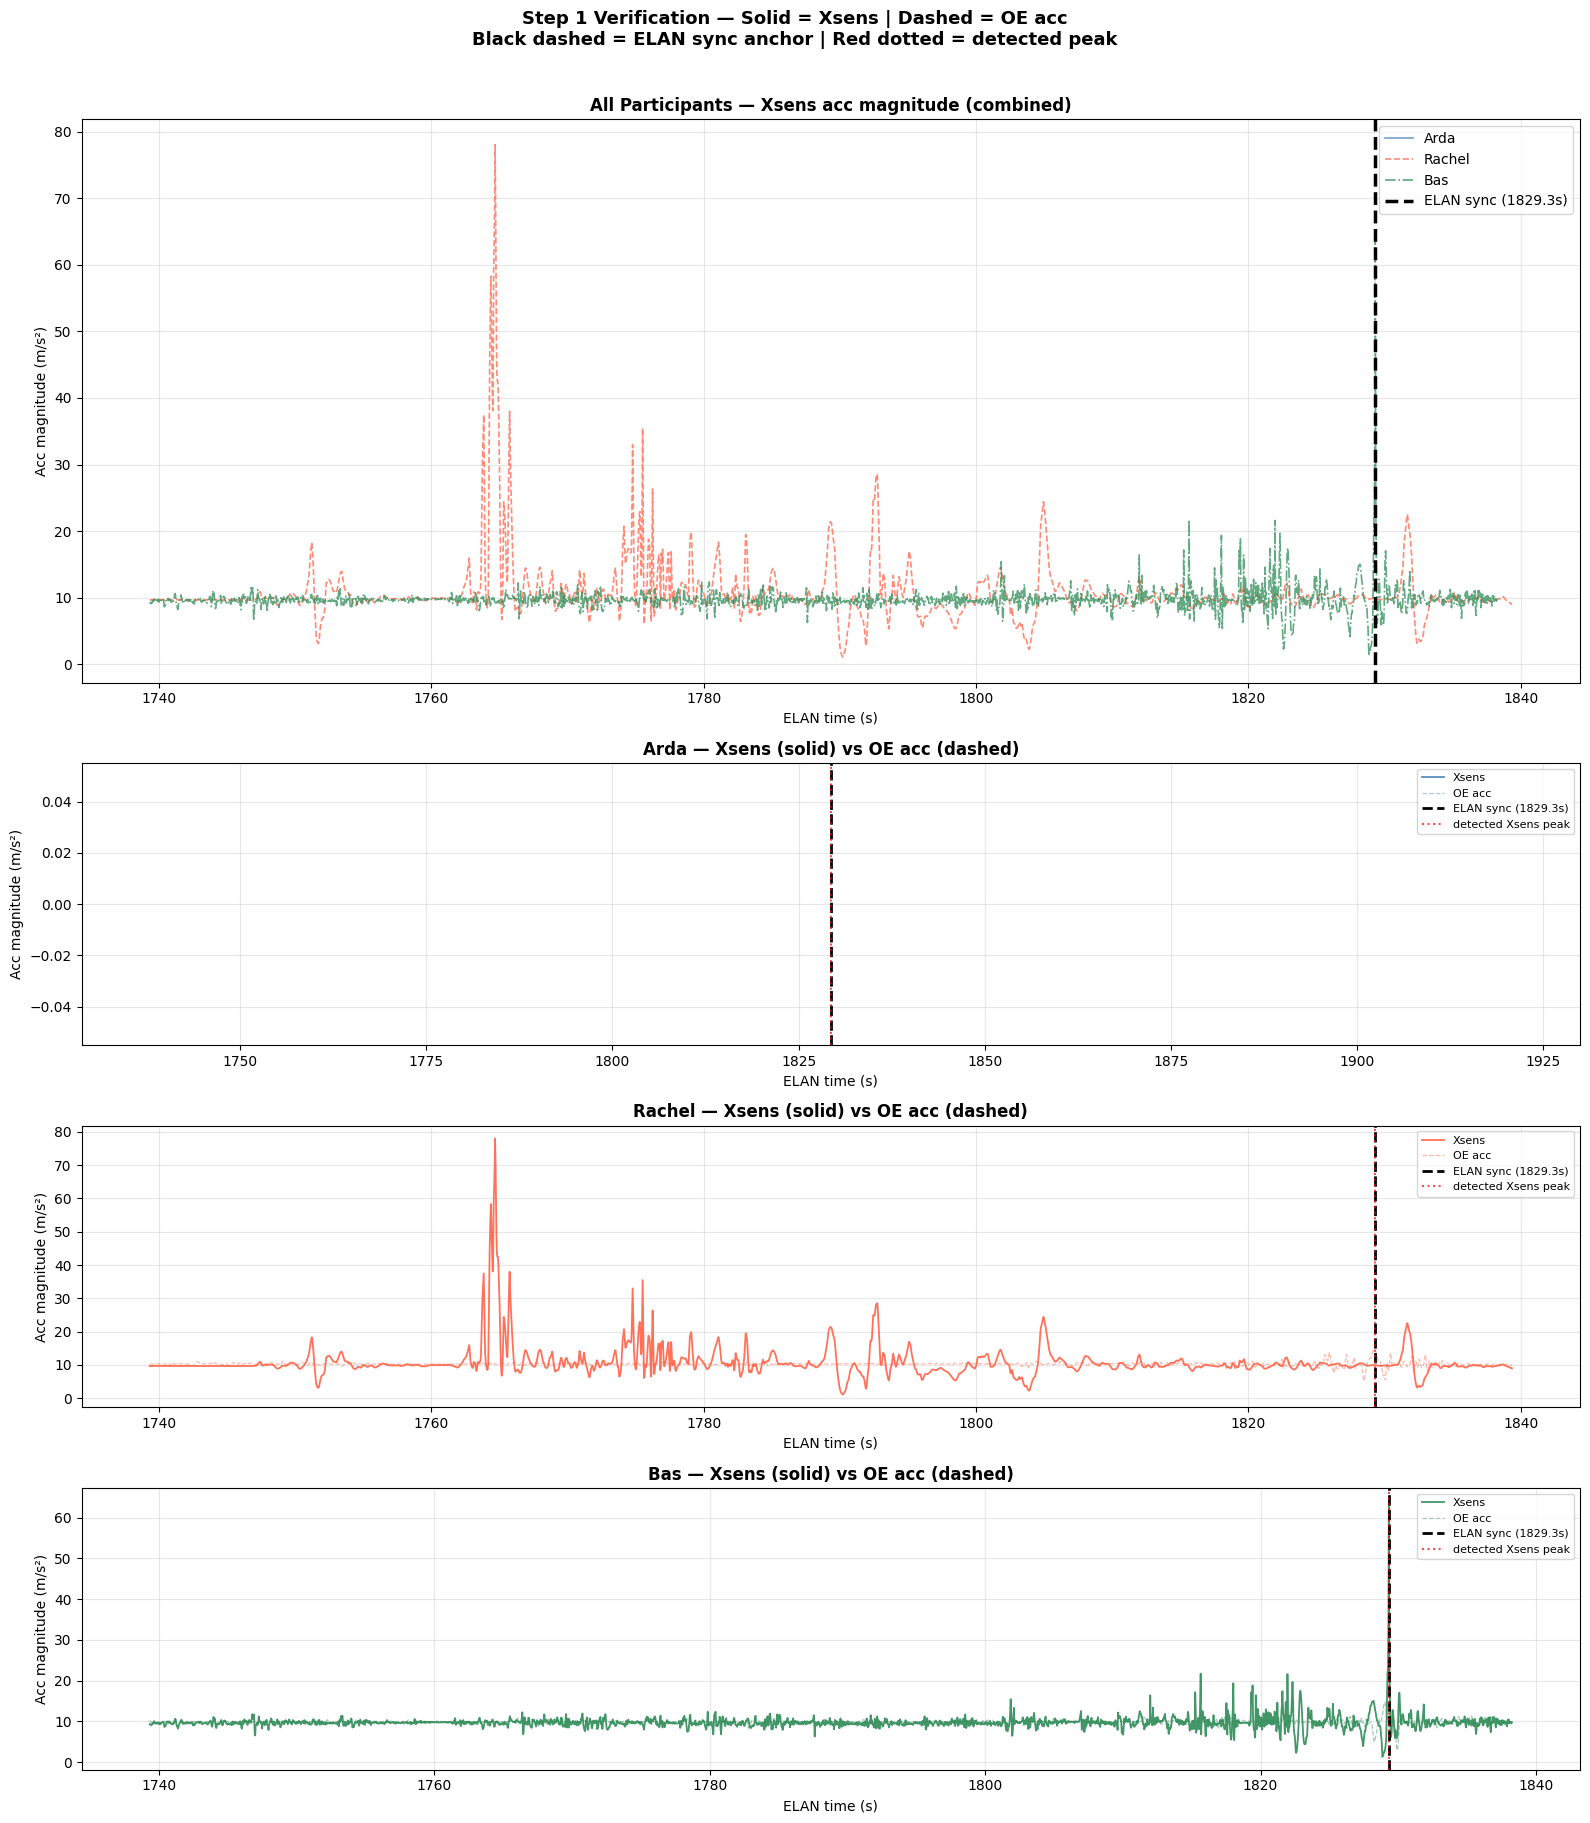

Saved output/group_1/step1_alignment_check.png

Peaks aligned with black line?  YES -> continue to Cell 6 (STEP 2)
                                NO  -> return to Cell 3b and override


In [10]:
fig, axes = plt.subplots(4, 1, figsize=(16, 18),
                         gridspec_kw={'height_ratios': [2, 1, 1, 1]})

colors     = ['steelblue', 'tomato', 'seagreen']
linestyles = ['-', '--', '-.']

# ── Panel 1: All 3 combined (Xsens) ──────────────────────────────────────────
ax = axes[0]
for name, color, ls in zip(PARTICIPANTS, colors, linestyles):
    df  = aligned[name]
    mag  = np.sqrt(df['xs_acc_x']**2 + df['xs_acc_y']**2 + df['xs_acc_z']**2).values
    mask = ((df['time_sec'] >= elan_sync_t - 90) & (df['time_sec'] <= elan_sync_t + 30)).values
    ax.plot(df['time_sec'].values[mask], mag[mask],
            label=name.capitalize(), color=color, lw=1.2, alpha=0.75, linestyle=ls)
ax.axvline(elan_sync_t, color='black', lw=2.5, ls='--',
           label=f'ELAN sync ({elan_sync_t:.1f}s)')
ax.set_title('All Participants — Xsens acc magnitude (combined)', fontweight='bold')
ax.set_xlabel('ELAN time (s)')
ax.set_ylabel('Acc magnitude (m/s\u00b2)')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Panels 2-4: One per participant (Xsens solid + OE dashed) ────────────────
for i, (name, color) in enumerate(zip(PARTICIPANTS, colors)):
    ax   = axes[i + 1]
    df   = aligned[name]
    mask = (df['time_sec'] >= elan_sync_t - 90) & (df['time_sec'] <= elan_sync_t + 30)
    t    = df.loc[mask, 'time_sec']

    xs_mag  = np.sqrt(df['xs_acc_x']**2 + df['xs_acc_y']**2 + df['xs_acc_z']**2).values
    oe_mag  = np.sqrt(df['oe_acc_x']**2 + df['oe_acc_y']**2 + df['oe_acc_z']**2).values
    mask_np = mask.values

    ax.plot(t, xs_mag[mask_np], color=color, lw=1.3, alpha=0.9,  label='Xsens')
    ax.plot(t, oe_mag[mask_np], color=color, lw=0.9, alpha=0.45,
            ls='--', label='OE acc')
    ax.axvline(elan_sync_t, color='black', lw=2, ls='--',
               label=f'ELAN sync ({elan_sync_t:.1f}s)')

    xs_off_i = elan_sync_t - sync_peaks[name]['xs']
    oe_off_i = elan_sync_t - sync_peaks[name]['oe']
    ax.set_title(f'{name.capitalize()} — Xsens (solid) vs OE acc (dashed)  '
                 f'[XS offset: {xs_off_i:+.1f}s | OE offset: {oe_off_i:+.1f}s]',
                 fontweight='bold')
    ax.set_xlabel('ELAN time (s)')
    ax.set_ylabel('Acc magnitude (m/s\u00b2)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Step 1 Verification — Solid = Xsens | Dashed = OE acc\n'
             'Black dashed = ELAN sync anchor | Red dotted = detected peak',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, 'step1_alignment_check.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved {fig_path}')
print()
print('Peaks aligned with black line?  YES -> continue to Cell 6 (STEP 2)')
print('                                NO  -> return to Cell 3b and override')

---
## STEP 2 — Group Synchronization
### Cell 6 — Merge All 3 Participants into One Wide CSV

- Finds the time window where **all 3 participants** have data simultaneously
- Resamples to a single shared time axis
- Adds **every ELAN label tier**: 3 individual + 3 pair + 1 whole-group
- Saves `group_synchronized.csv`

In [11]:
print('STEP 2  Group merge  ────────────────────────────────────────────────────')

# ── Shared time window ────────────────────────────────────────────────────────
t_start_g = max(df['time_sec'].iloc[0]  for df in aligned.values())
t_end_g   = min(df['time_sec'].iloc[-1] for df in aligned.values())
t_group   = np.arange(t_start_g, t_end_g, 1.0 / TARGET_HZ)

print(f'  Shared window : {t_start_g:.1f}s -> {t_end_g:.1f}s')
print(f'  Duration      : {(t_end_g - t_start_g)/60:.1f} min')
print(f'  Samples       : {len(t_group):,} @ {TARGET_HZ} Hz')
print()

group_out = {'time_sec': t_group}

# ── Sensor columns (prefixed with participant name) ───────────────────────────
for name in PARTICIPANTS:
    df      = aligned[name]
    t_src   = df['time_sec'].values
    s_cols  = [c for c in df.columns if not c.startswith('label') and c != 'time_sec']
    for col in s_cols:
        group_out[f'{name}_{col}'] = np.interp(t_group, t_src, df[col].values)
    print(f'  {name.capitalize():<10}: {len(s_cols)} sensor columns added')

# ── All ELAN label tiers ──────────────────────────────────────────────────────
print()
print('  Adding ELAN label columns...')

for name in PARTICIPANTS:
    group_out[f'label_{name}'] = assign_labels(t_group, elan_df, name.capitalize())

for tier in ELAN_PAIR_TIERS:
    group_out[f'label_{tier.lower()}'] = assign_labels(t_group, elan_df, tier)

group_out['label_whole_group'] = assign_labels(t_group, elan_df, ELAN_GROUP_TIER)

label_cols = [c for c in group_out if c.startswith('label_')]
print(f'  Label tiers added: {label_cols}')

# ── Save ──────────────────────────────────────────────────────────────────────
group_df = pd.DataFrame(group_out)
out_path = os.path.join(OUTPUT_DIR, 'group_synchronized.csv')
group_df.to_csv(out_path, index=False)

sensor_cols = [c for c in group_df.columns if not c.startswith('label') and c != 'time_sec']
print()
print(f'  Saved -> {out_path}')
print(f'  Shape : {group_df.shape[0]:,} rows x {group_df.shape[1]} columns')
print(f'           ({len(sensor_cols)} sensor cols + {len(label_cols)} label cols + 1 time col)')
print()
print('STEP 2 complete')

STEP 2  Group merge  ────────────────────────────────────────────────────
  Shared window : -155.8s -> 1074.9s
  Duration      : 20.5 min
  Samples       : 36,922 @ 30 Hz

  Arda      : 28 sensor columns added
  Rachel    : 28 sensor columns added
  Bas       : 28 sensor columns added

  Adding ELAN label columns...
  Label tiers added: ['label_arda', 'label_rachel', 'label_bas', 'label_bas_rachel', 'label_bas_arda', 'label_arda_rachel', 'label_whole_group']

  Saved -> output/group_1/group_synchronized.csv
  Shape : 36,922 rows x 92 columns
           (84 sensor cols + 7 label cols + 1 time col)

STEP 2 complete


## Cell 7 — Final Summary & Label Distribution

In [ ]:
print('=' * 62)
print('  PIPELINE COMPLETE')
print('=' * 62)
print()

# STEP 1 files
print('STEP 1 — Individual aligned files:')
print(f'  {"File":<30}  {"Duration":>9}  {"Cols":>5}  {"% labeled":>10}')
print('  ' + '-'*58)
for name in PARTICIPANTS:
    df  = aligned[name]
    dur = (df['time_sec'].iloc[-1] - df['time_sec'].iloc[0]) / 60
    pct = (df['label_individual'] != '').mean() * 100
    print(f'  {name}_aligned.csv{"":12}  {dur:>7.1f} min  {df.shape[1]:>5}  {pct:>9.0f}%')

print()

# STEP 2 file
print('STEP 2 — Group synchronized file:')
dur_g = (group_df['time_sec'].iloc[-1] - group_df['time_sec'].iloc[0]) / 60
print(f'  group_synchronized.csv')
print(f'  {group_df.shape[0]:,} rows x {group_df.shape[1]} columns | {dur_g:.1f} min')
print()

# Label breakdown
print('ELAN annotation coverage (in group_synchronized.csv):')
print()
all_tiers = ([f'label_{n}' for n in PARTICIPANTS]
           + [f'label_{t.lower()}' for t in ELAN_PAIR_TIERS]
           + ['label_whole_group'])

for tier in all_tiers:
    if tier not in group_df.columns:
        continue
    col    = group_df[tier]
    filled = (col != '').sum()
    pct    = filled / len(group_df) * 100
    top3   = col[col != ''].value_counts().head(3)
    print(f'  {tier}')
    print(f'    {filled:,}/{len(group_df):,} samples ({pct:.0f}%) annotated')
    for lbl, cnt in top3.items():
        print(f'    {cnt:6,} x  {lbl}')
    print()

# Sync offsets
print('Sync offsets applied:')
print(f'  {"Participant":<12}  {"Xsens offset":>14}  {"OE offset":>12}')
print('  ' + '-'*42)
for name in PARTICIPANTS:
    xs_off = elan_sync_t - sync_peaks[name]['xs']
    oe_off = elan_sync_t - sync_peaks[name]['oe']
    print(f'  {name.capitalize():<12}  {xs_off:>+12.3f}s  {oe_off:>+10.3f}s')

print()
print(f'All files saved to: {OUTPUT_DIR}/')
print('=' * 62)